# 05 — Modelli predittivi

Un modello per sport (regressione logistica binaria: il paese vince almeno una medaglia in quell'edizione?), con Random Forest e Gradient Boosting come confronto non lineare. Include l'effetto "paese ospitante" come variabile di controllo.

**File necessari:** `olympics_sport_cluster.csv`, `olympics_with_clusters.csv` (entrambi da notebook precedenti — questo notebook è altrimenti completamente autonomo)

In [12]:
# %% [1] IMPORT
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

CLUSTER_ORDER = ['Ricchi avanzati', 'Reddito medio-alto',
                 'Reddito basso-medio', 'Poveri estremi']


In [13]:
# %% [2] CARICAMENTO E COSTRUZIONE DEL DATASET BINARIO
# -----------------------------------------------------------------------------
# Unità di analisi: paese × edizione olimpica
# Per ogni coppia paese-anno abbiamo gli indicatori socioeconomici
# e, per ogni sport, un flag 1 (ha vinto almeno una medaglia) / 0 (non ha vinto)

sport_df  = pd.read_csv('olympics_sport_cluster.csv')
clustered = pd.read_csv('olympics_with_clusters.csv')

# FIX: alcune celle precedenti salvano la colonna come 'cluster_wb'
# invece di 'cluster_label' (dipende da quale cella ha scritto per
# ultima il CSV). Normalizziamo qui per essere robusti in ogni caso.
for _df in (sport_df, clustered):
    if 'cluster_label' not in _df.columns and 'cluster_wb' in _df.columns:
        _df.rename(columns={'cluster_wb': 'cluster_label'}, inplace=True)

INDICATORS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
              'infant_mortality', 'population']

# Step 1: dataset eventi con indicatori
df = sport_df.merge(
    clustered[['noc', 'year'] + INDICATORS],
    left_on=['NOC', 'Year'], right_on=['noc', 'year'], how='left'
)

event_df = (
    df.groupby(['Year', 'NOC', 'Sport', 'Event', 'Medal', 'cluster_label'] + INDICATORS)
    .size().reset_index(name='n')
).dropna(subset=INDICATORS)

# Step 2: base — tutti i paese-anno con indicatori disponibili
country_year = (
    clustered[['noc', 'year', 'cluster_label'] + INDICATORS]
    .dropna(subset=INDICATORS)
    .drop_duplicates(subset=['noc', 'year'])
)
print(f"Paese-anno osservazioni: {len(country_year):,}")

# Step 3: sport con almeno 50 medaglie totali
sport_counts = event_df['Sport'].value_counts()
SPORTS_OK = sport_counts[sport_counts >= 50].index.tolist()
print(f"Sport analizzati: {len(SPORTS_OK)}")
print(SPORTS_OK)

# Step 4: per ogni sport costruiamo il flag won=1/0
winners_by_sport = (
    event_df[event_df['Sport'].isin(SPORTS_OK)]
    .groupby(['NOC', 'Year', 'Sport'])['n']
    .sum().reset_index()
    .rename(columns={'NOC': 'noc', 'Year': 'year'})
)
winners_by_sport['won'] = 1

# Preprocessing comune (imputazione + normalizzazione)
imp    = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_base = country_year[INDICATORS].values
X_imp  = imp.fit_transform(X_base)
X_sc   = scaler.fit_transform(X_imp)


# --- Effetto "paese ospitante" (home advantage) ---
# I paesi che ospitano un'edizione vincono sistematicamente più medaglie.
# Lo aggiungiamo come variabile di controllo: senza, rischiamo di attribuire
# al PIL un effetto che in realtà dipende dal fatto che i paesi ricchi
# ospitano le Olimpiadi più spesso.
host_by_year = (
    clustered.dropna(subset=['host_country_code'])
    .groupby('year')['host_country_code']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
)

country_year['is_host'] = (
    country_year['noc'].astype(str).str.upper().str.strip()
    == country_year['year'].map(host_by_year).astype(str).str.upper().str.strip()
).astype(int)

n_host = country_year['is_host'].sum()
print(f"Paesi-anno ospitanti individuati: {n_host} su {len(country_year):,}")
if n_host == 0:
    print("⚠ Nessun host riconosciuto: controlla il formato di 'host_country_code' "
          "in olympics_with_clusters.csv (deve essere confrontabile con 'noc').")

# Il flag host non va standardizzato (resta 0/1, per un coefficiente
# direttamente interpretabile come differenza in log-odds host vs non-host)
FEATURES = INDICATORS + ['is_host']
X_sc = np.hstack([X_sc, country_year[['is_host']].values])

print(f"\nFeatures modello: {FEATURES}")

Paese-anno osservazioni: 2,423
Sport analizzati: 25
['Athletics', 'Swimming', 'Wrestling', 'Boxing', 'Judo', 'Shooting', 'Canoeing', 'Gymnastics', 'Cycling', 'Rowing', 'Fencing', 'Sailing', 'Weightlifting', 'Diving', 'Equestrianism', 'Taekwondo', 'Archery', 'Table Tennis', 'Tennis', 'Badminton', 'Modern Pentathlon', 'Volleyball', 'Basketball', 'Hockey', 'Synchronized Swimming']
Paesi-anno ospitanti individuati: 12 su 2,423

Features modello: ['gdp_per_capita', 'life_expectancy', 'urbanization_pct', 'infant_mortality', 'population', 'is_host']


In [14]:
# %% [3] REGRESSIONE BINARIA — UN MODELLO PER SPORT
# -----------------------------------------------------------------------------
# Per ogni sport:
#   - y = 1 se il paese ha vinto almeno 1 medaglia in quell'edizione, 0 altrimenti
#   - class_weight='balanced' compensa lo sbilanciamento (pochi vincitori)
#   - AUC-ROC è la metrica principale: misura quanto bene il modello separa
#     vincitori da non vincitori (0.5 = casuale, 1.0 = perfetto)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for sport in SPORTS_OK:
    # Costruisci y per questo sport
    w = winners_by_sport[winners_by_sport['Sport'] == sport][['noc', 'year', 'won']]
    merged = country_year[['noc', 'year']].merge(w, on=['noc', 'year'], how='left')
    y = merged['won'].fillna(0).astype(int).values

    # Fit
    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        class_weight='balanced',  # gestisce lo sbilanciamento delle classi
        random_state=42
    )

    # AUC-ROC in cross-validation
    auc_scores = cross_val_score(model, X_sc, y, cv=cv, scoring='roc_auc')

    # Fit su tutti i dati per estrarre coefficienti
    model.fit(X_sc, y)
    coefs = dict(zip(FEATURES, model.coef_[0]))  # FEATURES = INDICATORS + ['is_host']

    results.append({
        'sport':          sport,
        'n_winners':      y.sum(),
        'pct_winners':    y.mean() * 100,
        'auc_mean':       auc_scores.mean(),
        'auc_std':        auc_scores.std(),
        **{f'coef_{k}': v for k, v in coefs.items()}
    })

results_df = pd.DataFrame(results).sort_values('auc_mean', ascending=False)

print("=== AUC-ROC PER SPORT (ordinato dal più predittivo) ===")
print(f"{'Sport':<25} {'AUC':>6} {'±':>5} {'Vincitori':>10}")
for _, row in results_df.iterrows():
    bar = '█' * int(row['auc_mean'] * 20)
    print(f"{row['sport']:<25} {row['auc_mean']:.3f} ±{row['auc_std']:.3f}  "
          f"{int(row['n_winners']):>5} ({row['pct_winners']:.1f}%)  {bar}")


=== AUC-ROC PER SPORT (ordinato dal più predittivo) ===
Sport                        AUC     ±  Vincitori
Badminton                 0.975 ±0.017     27 (1.1%)  ███████████████████
Synchronized Swimming     0.971 ±0.015     29 (1.2%)  ███████████████████
Table Tennis              0.955 ±0.026     32 (1.3%)  ███████████████████
Archery                   0.939 ±0.015     66 (2.7%)  ██████████████████
Tennis                    0.933 ±0.030     62 (2.6%)  ██████████████████
Diving                    0.930 ±0.028     70 (2.9%)  ██████████████████
Gymnastics                0.914 ±0.023     94 (3.9%)  ██████████████████
Volleyball                0.907 ±0.043     50 (2.1%)  ██████████████████
Canoeing                  0.896 ±0.012    144 (5.9%)  █████████████████
Basketball                0.893 ±0.035     45 (1.9%)  █████████████████
Cycling                   0.891 ±0.023    129 (5.3%)  █████████████████
Rowing                    0.889 ±0.019    149 (6.1%)  █████████████████
Swimming           

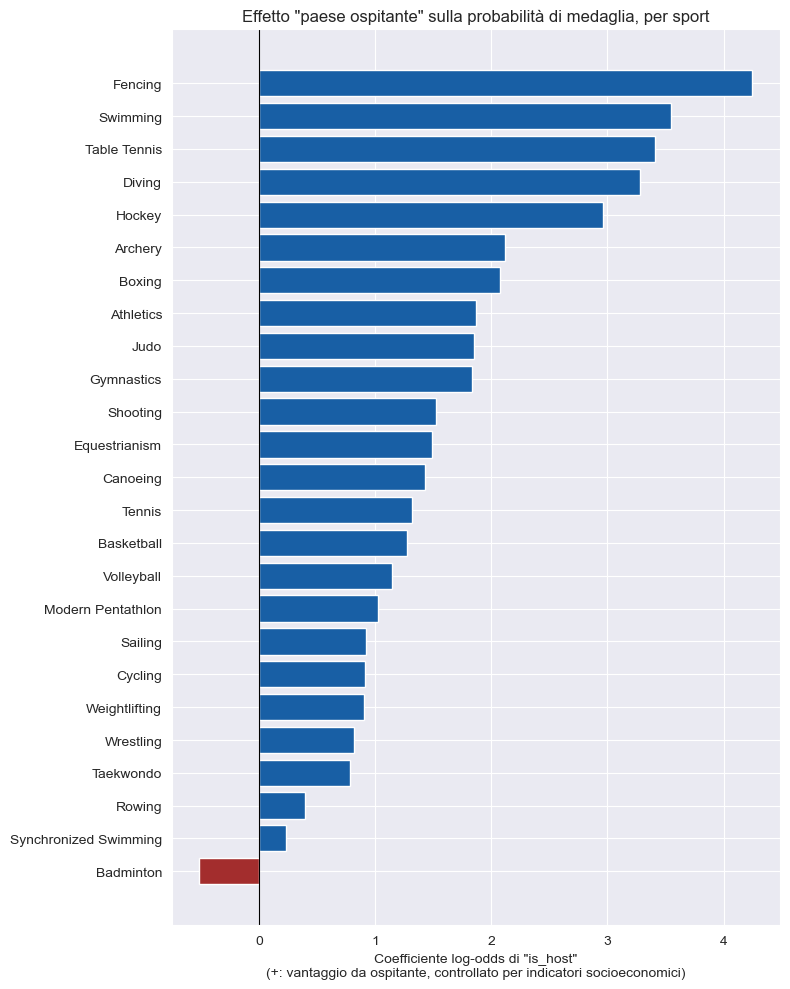

✓ Salvato: effetto_host_per_sport.png

                sport  coef_is_host  auc_mean
              Fencing         4.247     0.882
             Swimming         3.551     0.886
         Table Tennis         3.406     0.955
               Diving         3.279     0.930
               Hockey         2.964     0.855
              Archery         2.122     0.939
               Boxing         2.077     0.749
            Athletics         1.871     0.766
                 Judo         1.850     0.856
           Gymnastics         1.837     0.914
             Shooting         1.522     0.871
        Equestrianism         1.491     0.878
             Canoeing         1.433     0.896
               Tennis         1.323     0.933
           Basketball         1.278     0.893
           Volleyball         1.149     0.907
    Modern Pentathlon         1.024     0.864
              Sailing         0.923     0.886
              Cycling         0.916     0.891
        Weightlifting         0.904     0

In [15]:
# %% [3b] EFFETTO "PAESE OSPITANTE" PER SPORT
# -----------------------------------------------------------------------------
# Quanto pesa ospitare l'edizione, sport per sport? Coefficiente log-odds
# di 'is_host' dal modello binario di ciascuno sport (controllato per gli
# indicatori socioeconomici).

host_effect = (
    results_df[['sport', 'coef_is_host', 'auc_mean']]
    .sort_values('coef_is_host', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 10))
colors_bar = ['#185FA5' if v >= 0 else '#A32D2D' for v in host_effect['coef_is_host']]
ax.barh(host_effect['sport'], host_effect['coef_is_host'], color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Coefficiente log-odds di "is_host"\n(+: vantaggio da ospitante, controllato per indicatori socioeconomici)')
ax.set_title('Effetto "paese ospitante" sulla probabilità di medaglia, per sport', fontsize=12)
plt.tight_layout()
plt.savefig('effetto_host_per_sport.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: effetto_host_per_sport.png")

print()
print(host_effect.round(3).to_string(index=False))

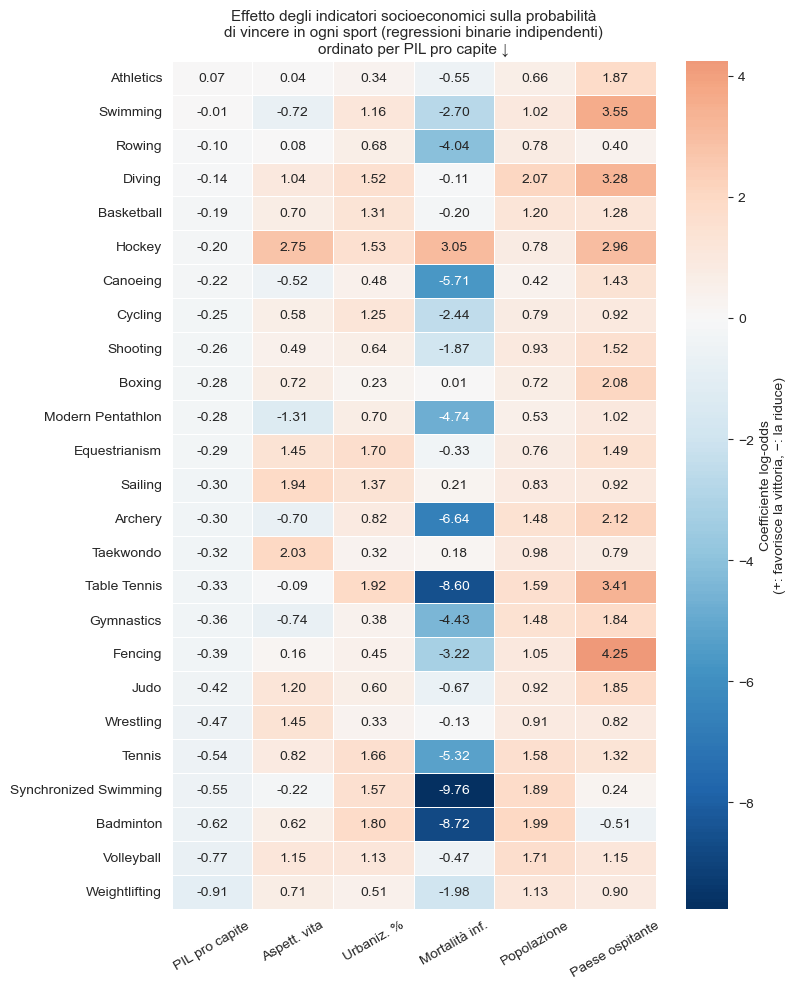

✓ Salvato: coeff_binarie.png


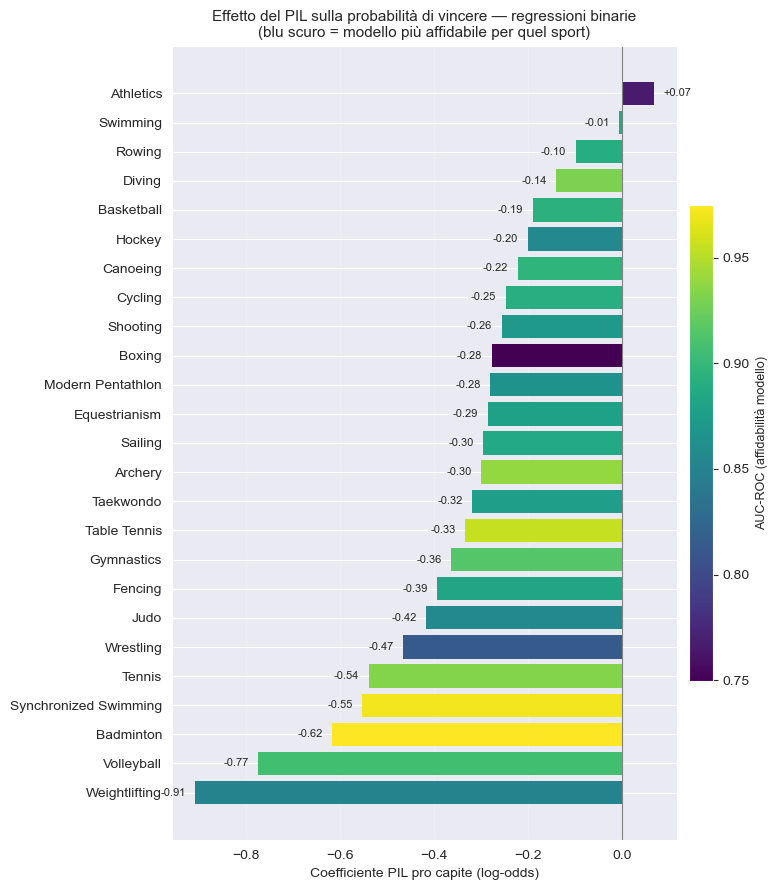

✓ Salvato: coeff_gdp_binarie.png


In [16]:
# %% [4] HEATMAP COEFFICIENTI — INTERPRETAZIONE DIRETTA
# -----------------------------------------------------------------------------
# Ogni cella = coefficiente log-odds per quell'indicatore in quel modello.
# Positivo = quell'indicatore aumenta la probabilità di vincere in quello sport.
# Negativo = la riduce.
# I coefficienti ora sono interpretabili senza ambiguità perché ogni modello
# è binario e indipendente dagli altri.

coef_cols = [f'coef_{i}' for i in FEATURES]
coef_labels = {
    'coef_gdp_per_capita':   'PIL pro capite',
    'coef_life_expectancy':  'Aspett. vita',
    'coef_urbanization_pct': 'Urbaniz. %',
    'coef_infant_mortality': 'Mortalità inf.',
    'coef_population':       'Popolazione',
    'coef_is_host':           'Paese ospitante',
}

# Ordiniamo per AUC e poi per coeff GDP
coef_matrix = results_df.set_index('sport')[coef_cols].rename(columns=coef_labels)
coef_matrix = coef_matrix.sort_values('PIL pro capite', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    coef_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Coefficiente log-odds\n(+: favorisce la vittoria, −: la riduce)'}
)
ax.set_title(
    'Effetto degli indicatori socioeconomici sulla probabilità\n'
    'di vincere in ogni sport (regressioni binarie indipendenti)\n'
    'ordinato per PIL pro capite ↓',
    fontsize=11
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('coeff_binarie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: coeff_binarie.png")


# %% [5] FOCUS PIL — IL GRAFICO PIÙ LEGGIBILE PER LA TESI
# -----------------------------------------------------------------------------
# Bar chart orizzontale: un bar per sport, colore per AUC (affidabilità modello)
# Sport ordinati da "più favorito da PIL alto" a "più favorito da PIL basso"

gdp_sorted = results_df.sort_values('coef_gdp_per_capita', ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))
norm = plt.Normalize(results_df['auc_mean'].min(), results_df['auc_mean'].max())
cmap = plt.cm.viridis
colors = [cmap(norm(v)) for v in gdp_sorted['auc_mean']]

bars = ax.barh(gdp_sorted['sport'], gdp_sorted['coef_gdp_per_capita'],
               color=colors, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)

# Colorbar per AUC
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('AUC-ROC (affidabilità modello)', fontsize=9)

# Etichette coefficiente
for bar, val in zip(bars, gdp_sorted['coef_gdp_per_capita']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

ax.set_xlabel('Coefficiente PIL pro capite (log-odds)')
ax.set_title(
    'Effetto del PIL sulla probabilità di vincere — regressioni binarie\n'
    '(blu scuro = modello più affidabile per quel sport)',
    fontsize=11
)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('coeff_gdp_binarie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: coeff_gdp_binarie.png")


In [17]:
# %% [6] PROBABILITÀ PREDETTE — 4 PROFILI PAESE
# -----------------------------------------------------------------------------
# Per ogni sport stimiamo la probabilità di vincere almeno una medaglia
# per i 4 profili paese che rappresentano i nostri cluster.

# I 4 profili-paese sono ora la mediana REALE degli indicatori all'interno
# di ciascun cluster MULTIVARIATO (non più valori scelti a mano), cosi'
# restano coerenti con l'etichetta di cluster usata in tutte le altre analisi
# (sport, mobilita', modelli non lineari).
cluster_profile_medians = (
    country_year.groupby('cluster_label')[INDICATORS]
    .median()
    .reindex(CLUSTER_ORDER)
    .dropna(how='all')
)
print("=== PROFILI PAESE — MEDIANA DEGLI INDICATORI PER CLUSTER MULTIVARIATO ===")
print(cluster_profile_medians.round(1).to_string())

profiles = {
    f"{label}\n(PIL {int(round(cluster_profile_medians.loc[label, 'gdp_per_capita'] / 1000))}k)":
        cluster_profile_medians.loc[label, INDICATORS].tolist()
    for label in CLUSTER_ORDER if label in cluster_profile_medians.index
}

prob_records = []
for sport in SPORTS_OK:
    w = winners_by_sport[winners_by_sport['Sport'] == sport][['noc', 'year', 'won']]
    merged = country_year[['noc', 'year']].merge(w, on=['noc', 'year'], how='left')
    y = merged['won'].fillna(0).astype(int).values

    model = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0,
                               class_weight='balanced', random_state=42)
    model.fit(X_sc, y)

    for profile_name, values in profiles.items():
        x = np.array(values).reshape(1, -1)
        x_imp = imp.transform(x)
        x_sc  = scaler.transform(x_imp)
        # I profili sono archetipi generici, non uno specifico paese host
        # di una specifica edizione: assumiamo is_host = 0
        x_sc  = np.hstack([x_sc, [[0]]])
        prob  = model.predict_proba(x_sc)[0][1]
        prob_records.append({
            'sport': sport, 'profile': profile_name, 'prob': prob * 100
        })

prob_df = pd.DataFrame(prob_records)
prob_pivot = prob_df.pivot(index='sport', columns='profile', values='prob')

# Ordiniamo per differenza tra ricchi e poveri (evidenzia gli sport più polarizzati)
profile_rich = [p for p in prob_pivot.columns if 'Ricchi' in p][0]
profile_poor = [p for p in prob_pivot.columns if 'Poveri' in p][0]
prob_pivot['gap'] = prob_pivot[profile_rich] - prob_pivot[profile_poor]
prob_pivot = prob_pivot.sort_values('gap', ascending=False).drop(columns='gap')

print("=== PROBABILITÀ PREDETTE DI VINCERE (%) ===")
print(prob_pivot.round(1).to_string())


=== PROFILI PAESE — MEDIANA DEGLI INDICATORI PER CLUSTER MULTIVARIATO ===
                     gdp_per_capita  life_expectancy  urbanization_pct  infant_mortality  population
cluster_label                                                                                       
Ricchi avanzati             18617.1             76.4              80.1               7.6   6490365.0
Reddito medio-alto           2248.6             69.1              55.2              26.5   4915600.6
Reddito basso-medio           504.5             57.0              24.9              71.2   6147779.8
Poveri estremi                420.8             51.1              28.6              99.9   7608709.5
=== PROBABILITÀ PREDETTE DI VINCERE (%) ===
profile                Poveri estremi\n(PIL 0k)  Reddito basso-medio\n(PIL 1k)  Reddito medio-alto\n(PIL 2k)  Ricchi avanzati\n(PIL 19k)
sport                                                                                                                                   
Ca

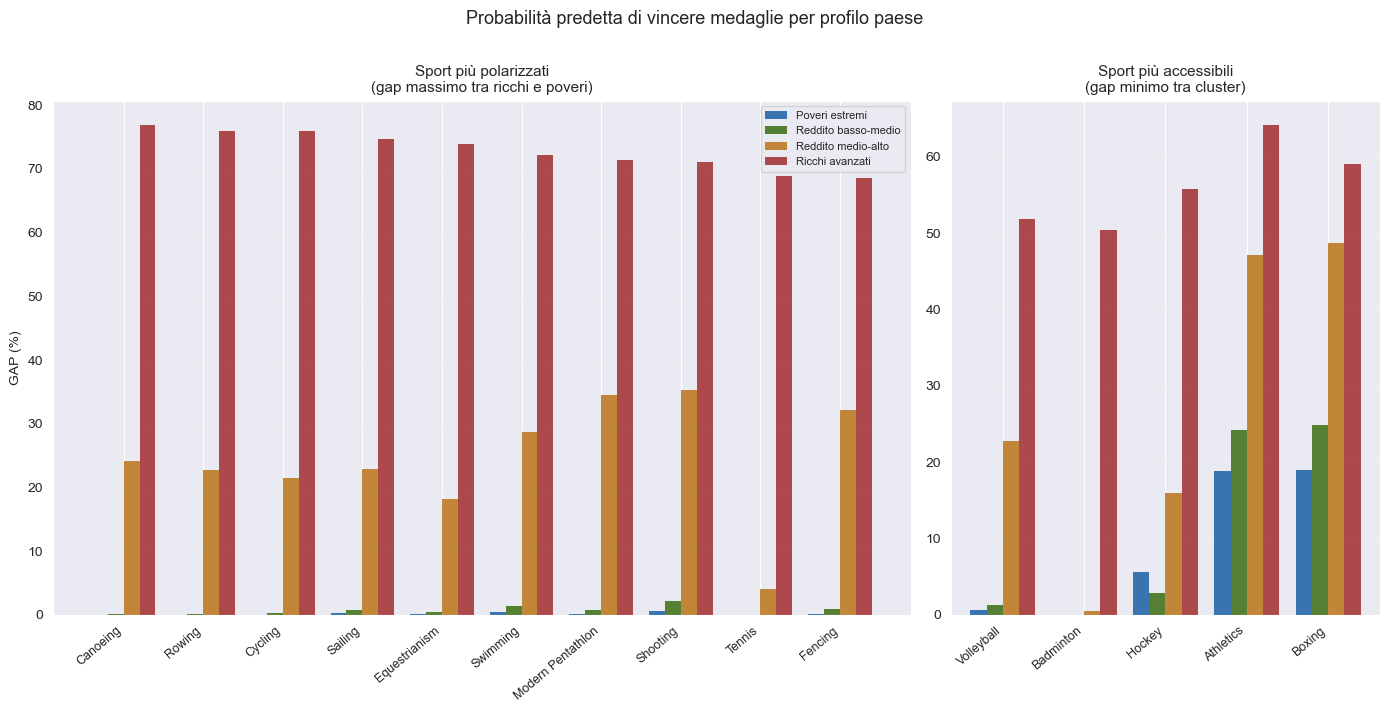

✓ Salvato: prob_predette_binarie.png


In [18]:
# -----------------------------------------------------------------------------
# Mostriamo i 10 sport con maggiore gap tra ricchi e poveri
# e i 5 sport più "equi" (gap minimo)

gap = (prob_pivot[profile_rich] - prob_pivot[profile_poor]).abs().sort_values(ascending=False)
top_polarized = gap.head(10).index.tolist()
top_equal     = gap.tail(5).index.tolist()
sports_plot   = top_polarized + top_equal

prob_plot = prob_pivot.loc[sports_plot]

profile_colors = ['#185FA5', '#3B6D11', '#BA7517', '#A32D2D']
profile_labels = [c.split('\n')[0] for c in prob_pivot.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                          gridspec_kw={'width_ratios': [2, 1]})

# Pannello sinistro: sport più polarizzati
ax = axes[0]
x = np.arange(len(top_polarized))
w = 0.2
for i, (col, color) in enumerate(zip(prob_plot.columns, profile_colors)):
    label = col.split('\n')[0]
    ax.bar(x + i * w, prob_plot.loc[top_polarized, col],
           w, label=label, color=color, alpha=0.85, edgecolor='none')
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(top_polarized, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('GAP (%)')
ax.set_title('Sport più polarizzati\n(gap massimo tra ricchi e poveri)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

# Pannello destro: sport più equi
ax = axes[1]
x2 = np.arange(len(top_equal))
for i, (col, color) in enumerate(zip(prob_plot.columns, profile_colors)):
    ax.bar(x2 + i * w, prob_plot.loc[top_equal, col],
           w, color=color, alpha=0.85, edgecolor='none')
ax.set_xticks(x2 + w * 1.5)
ax.set_xticklabels(top_equal, rotation=40, ha='right', fontsize=9)
ax.set_title('Sport più accessibili\n(gap minimo tra cluster)', fontsize=11)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Probabilità predetta di vincere medaglie per profilo paese',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('prob_predette_binarie.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: prob_predette_binarie.png")


## Confronto con modelli non lineari (Random Forest / Gradient Boosting)

La
regressione
logistica
resta
il
modello
di
riferimento
per
la
tesi, perché
i
suoi
coefficienti
sono
interpretabili
direttamente
come
log - odds
e
alimentano
l
'heatmap e le probabilità predette della sezione precedente. Qui la usiamo come **benchmark**: alleniamo un Random Forest e un Gradient Boosting sugli stessi dati (stesse feature standardizzate, stessa cross-validation StratifiedKFold a 5 fold), sport per sport, e confrontiamo l'
AUC - ROC.Se
i
modelli
non
lineari
non
migliorano in modo
sostanziale, è
un
'evidenza a favore del fatto che la relazione tra indicatori socioeconomici e probabilità di medaglia è ragionevolmente lineare/monotona nello sport in questione; dove invece migliorano parecchio, è un segnale di soglie o interazioni che la regressione non cattura, da approfondire.

In [ ]:
# %% [9] RANDOM FOREST E GRADIENT BOOSTING — STESSO SETUP DELLA LOGISTICA
# -----------------------------------------------------------------------------
# Riusiamo X_sc, FEATURES, country_year, winners_by_sport, cv già costruiti
# nella sezione di regressione. Iperparametri tenuti volutamente conservativi
# (alberi poco profondi, min_samples_leaf non troppo piccolo): con poche
# centinaia/migliaia di osservazioni per sport e classi sbilanciate, modelli
# troppo flessibili rischiano di overfittare più della logistica.

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

nonlin_results = []

for sport in SPORTS_OK:
    w = winners_by_sport[winners_by_sport['Sport'] == sport][['noc', 'year', 'won']]
    merged = country_year[['noc', 'year']].merge(w, on=['noc', 'year'], how='left')
    y = merged['won'].fillna(0).astype(int).values

    rf = RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    # Nota: GradientBoostingClassifier (a differenza di RandomForest) non
    # supporta class_weight; le classi restano sbilanciate in questo modello
    # (vedi nota metodologica in fondo alla sezione).
    gbm = GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    )

    auc_rf  = cross_val_score(rf,  X_sc, y, cv=cv, scoring='roc_auc')
    auc_gbm = cross_val_score(gbm, X_sc, y, cv=cv, scoring='roc_auc')

    # Fit su tutti i dati per estrarre la feature importance
    rf.fit(X_sc, y)
    gbm.fit(X_sc, y)

    nonlin_results.append({
        'sport': sport,
        'auc_rf_mean':  auc_rf.mean(),  'auc_rf_std':  auc_rf.std(),
        'auc_gbm_mean': auc_gbm.mean(), 'auc_gbm_std': auc_gbm.std(),
        **{f'rf_imp_{f}':  v for f, v in zip(FEATURES, rf.feature_importances_)},
        **{f'gbm_imp_{f}': v for f, v in zip(FEATURES, gbm.feature_importances_)},
    })

nonlin_df = pd.DataFrame(nonlin_results)

comparison_models = (
    results_df[['sport', 'auc_mean', 'n_winners', 'pct_winners']]
    .rename(columns={'auc_mean': 'auc_logistic'})
    .merge(nonlin_df[['sport', 'auc_rf_mean', 'auc_gbm_mean']], on='sport')
)
comparison_models['delta_rf']  = comparison_models['auc_rf_mean']  - comparison_models['auc_logistic']
comparison_models['delta_gbm'] = comparison_models['auc_gbm_mean'] - comparison_models['auc_logistic']

print("=== AUC: LOGISTICA vs RANDOM FOREST vs GRADIENT BOOSTING ===")
print(comparison_models.sort_values('delta_gbm', ascending=False).round(3).to_string(index=False))

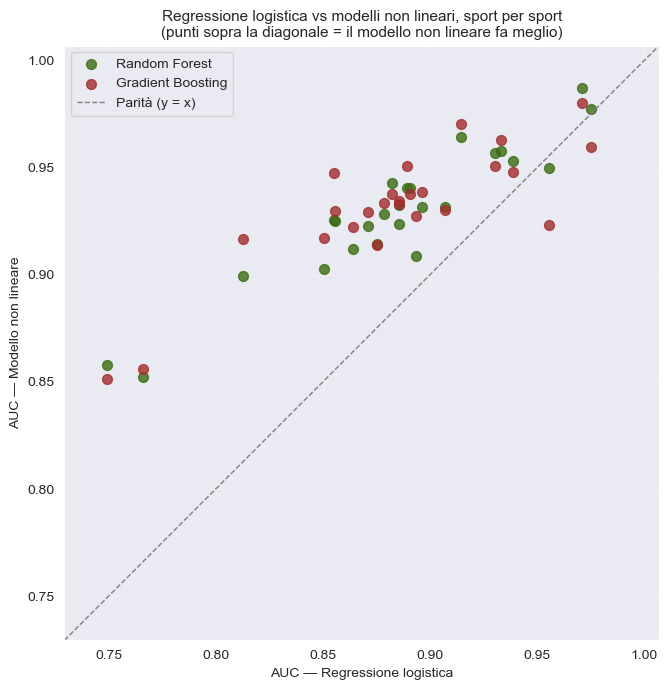

✓ Salvato: confronto_auc_modelli.png

Sport in cui il Random Forest supera la logistica di almeno 0.01 AUC: 23/25
Sport in cui il Gradient Boosting supera la logistica di almeno 0.01 AUC: 21/25


In [9]:
# %% [9b] AUC A CONFRONTO — SCATTER LOGISTICA vs MODELLI NON LINEARI
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(comparison_models['auc_logistic'], comparison_models['auc_rf_mean'],
           color='#3B6D11', label='Random Forest', alpha=0.8, s=50)
ax.scatter(comparison_models['auc_logistic'], comparison_models['auc_gbm_mean'],
           color='#A32D2D', label='Gradient Boosting', alpha=0.8, s=50)

all_vals = comparison_models[['auc_logistic', 'auc_rf_mean', 'auc_gbm_mean']]
lims = [all_vals.min().min() - 0.02, all_vals.max().max() + 0.02]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1, label='Parità (y = x)')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.set_xlabel('AUC — Regressione logistica')
ax.set_ylabel('AUC — Modello non lineare')
ax.set_title(
    'Regressione logistica vs modelli non lineari, sport per sport\n'
    '(punti sopra la diagonale = il modello non lineare fa meglio)',
    fontsize=11
)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('confronto_auc_modelli.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: confronto_auc_modelli.png")

n_rf_better  = (comparison_models['delta_rf']  > 0.01).sum()
n_gbm_better = (comparison_models['delta_gbm'] > 0.01).sum()
print(f"\nSport in cui il Random Forest supera la logistica di almeno 0.01 AUC: "
      f"{n_rf_better}/{len(comparison_models)}")
print(f"Sport in cui il Gradient Boosting supera la logistica di almeno 0.01 AUC: "
      f"{n_gbm_better}/{len(comparison_models)}")

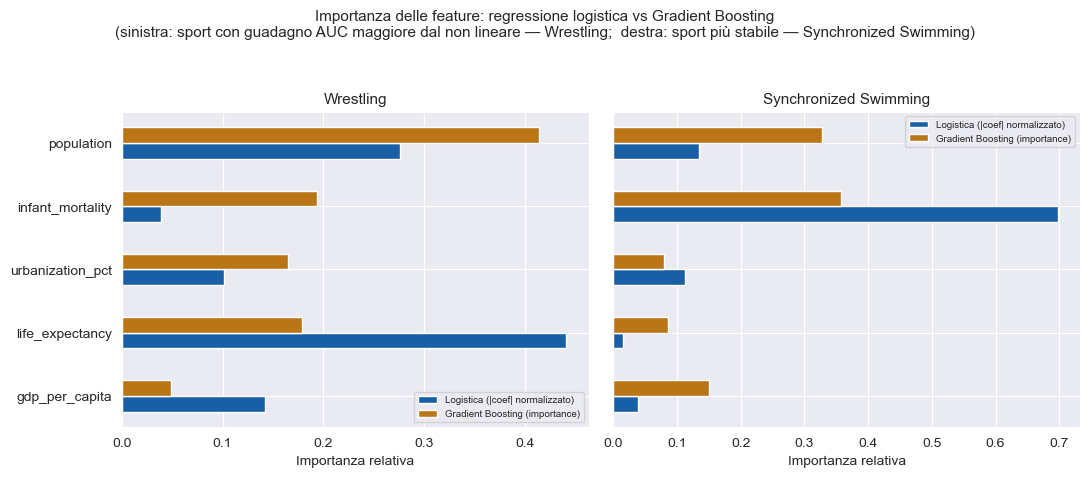

✓ Salvato: confronto_importanza_feature.png


In [10]:
# %% [9c] IMPORTANZA DELLE FEATURE — LOGISTICA vs GRADIENT BOOSTING
# -----------------------------------------------------------------------------
# Confrontiamo, per due sport rappresentativi, l'ordine di importanza degli
# indicatori tra i due approcci: se coincide, il risultato della regressione
# è più solido; se no, segnala che il modello lineare sta semplificando troppo.
#   - 'sport_gain'   = sport dove il non lineare guadagna di più rispetto alla
#                      logistica (possibile non linearità/interazioni)
#   - 'sport_stable' = sport dove i due modelli sono più vicini (delta minimo)

sport_gain   = comparison_models.sort_values('delta_gbm', ascending=False)['sport'].iloc[0]
sport_stable = comparison_models.loc[comparison_models['delta_gbm'].abs().idxmin(), 'sport']

FEATURES_SOCIO = [f for f in FEATURES if f != 'is_host']


def get_importance_frame(sport):
    logi_coefs = results_df.set_index('sport').loc[sport, [f'coef_{f}' for f in FEATURES_SOCIO]]
    logi_coefs.index = FEATURES_SOCIO
    logi_norm = logi_coefs.abs() / logi_coefs.abs().sum()

    gbm_imp = nonlin_df.set_index('sport').loc[sport, [f'gbm_imp_{f}' for f in FEATURES_SOCIO]]
    gbm_imp.index = FEATURES_SOCIO
    gbm_norm = gbm_imp / gbm_imp.sum()

    return pd.DataFrame({
        'Logistica (|coef| normalizzato)': logi_norm,
        'Gradient Boosting (importance)': gbm_norm,
    })


sports_compare = [sport_gain, sport_stable]

fig, axes = plt.subplots(1, len(sports_compare), figsize=(11, 4.5), sharey=True)
for ax, sport in zip(axes, sports_compare):
    frame = get_importance_frame(sport)
    frame.plot(kind='barh', ax=ax, color=['#185FA5', '#BA7517'])
    ax.set_title(sport, fontsize=11)
    ax.set_xlabel('Importanza relativa')
    ax.legend(fontsize=7)

plt.suptitle(
    'Importanza delle feature: regressione logistica vs Gradient Boosting\n'
    f'(sinistra: sport con guadagno AUC maggiore dal non lineare — {sport_gain};  '
    f'destra: sport più stabile — {sport_stable})',
    fontsize=11, y=1.05
)
plt.tight_layout()
plt.savefig('confronto_importanza_feature.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: confronto_importanza_feature.png")

### Nota metodologica — regressione vs modelli non lineari

- ** Iperparametri
conservativi
apposta **: alberi
poco
profondi(`max_depth`
3 - 5) e
`min_samples_leaf = 5
` per
il
Random
Forest, per
limitare
l
'overfitting su campioni per sport spesso piccoli e sbilanciati (pochi "vincitori"). Con iperparametri più aggressivi l'
AUC in training
salirebbe, ma
quella in cross - validation(l
'unica che conta) probabilmente peggiorerebbe.
- ** Sbilanciamento
delle
classi **: `RandomForestClassifier`
gestisce
lo
sbilanciamento
con
`class_weight = 'balanced'
`, come
la
logistica;
`GradientBoostingClassifier`
invece
non
supporta
questo
parametro, quindi
il
confronto
non
è
perfettamente
alla
pari.Se
il
divario
AUC
risultasse
rilevante, vale
la
pena
ripetere
il
confronto
con
`HistGradientBoostingClassifier`(supporta
`sample_weight` /


class balancing nelle versioni recenti di scikit-learn) prima di trarre conclusioni definitive su quello sport.
- ** Feature importance dei modelli ad albero ** non è direttamente comparabile ai coefficienti log-odds della logistica: qui


viene
solo
normalizzata
per
leggere
l
'ordine relativo, non l'
entità
dell
'effetto. Le importance di RF/GBM tendono inoltre a favorire variabili continue con molti valori distinti (PIL, popolazione) rispetto a variabili quasi-binarie: per un confronto più rigoroso si potrebbe usare la permutation importance (`sklearn.inspection.permutation_importance`) invece della importance nativa.
- ** Come
leggere
il
risultato
per
la
tesi **: se
per
la
maggior
parte
degli
sport
`delta_rf`
e
`delta_gbm`
sono
piccoli, è
una
conferma
che
la
regressione
logistica — pur
più
semplice — non
sta
perdendo
molta
capacità
predittiva, e
i
suoi
coefficienti
restano
l
'evidenza principale da citare. Gli sport con guadagno maggiore dal modello non lineare vanno invece segnalati esplicitamente come casi in cui la relazione PIL-medaglie non è puramente lineare.

In [11]:

# %% [8] SINTESI — RISULTATI PER LA TESI
# -----------------------------------------------------------------------------
print("=" * 60)
print("SINTESI RISULTATI — REGRESSIONI BINARIE")
print("=" * 60)
print()
print(f"Modelli addestrati: {len(SPORTS_OK)} (uno per sport)")
print(f"Osservazioni per modello: {len(country_year):,} paese-anno")
print(f"Metrica: AUC-ROC in cross-validation 5-fold")
print()

best = results_df.nlargest(5, 'auc_mean')[['sport','auc_mean','auc_std']]
worst = results_df.nsmallest(5, 'auc_mean')[['sport','auc_mean','auc_std']]
print("--- SPORT PIÙ PREDITTIBILI (AUC alto) ---")
for _, r in best.iterrows():
    print(f"  {r['sport']:<25} AUC={r['auc_mean']:.3f} ±{r['auc_std']:.3f}")
print()
print("--- SPORT MENO PREDITTIBILI (AUC basso) ---")
for _, r in worst.iterrows():
    print(f"  {r['sport']:<25} AUC={r['auc_mean']:.3f} ±{r['auc_std']:.3f}")
print()

rich_sports = results_df.nlargest(5, 'coef_gdp_per_capita')[['sport','coef_gdp_per_capita']]
poor_sports = results_df.nsmallest(5, 'coef_gdp_per_capita')[['sport','coef_gdp_per_capita']]
print("--- SPORT PIÙ FAVORITI DA PIL ALTO ---")
for _, r in rich_sports.iterrows():
    print(f"  {r['sport']:<25} β={r['coef_gdp_per_capita']:+.3f}")
print()
print("--- SPORT PIÙ FAVORITI DA PIL BASSO ---")
for _, r in poor_sports.iterrows():
    print(f"  {r['sport']:<25} β={r['coef_gdp_per_capita']:+.3f}")
print()
print("Nota metodologica:")
print("  β = coefficiente log-odds. Un β=+0.5 per il PIL nel nuoto significa")
print("  che all'aumentare di 1 deviazione standard del PIL, le probabilità")
print("  (in log-odds) di vincere nel nuoto aumentano di 0.5.")



SINTESI RISULTATI — REGRESSIONI BINARIE

Modelli addestrati: 25 (uno per sport)
Osservazioni per modello: 2,423 paese-anno
Metrica: AUC-ROC in cross-validation 5-fold

--- SPORT PIÙ PREDITTIBILI (AUC alto) ---
  Badminton                 AUC=0.975 ±0.017
  Synchronized Swimming     AUC=0.971 ±0.015
  Table Tennis              AUC=0.955 ±0.026
  Archery                   AUC=0.939 ±0.015
  Tennis                    AUC=0.933 ±0.030

--- SPORT MENO PREDITTIBILI (AUC basso) ---
  Boxing                    AUC=0.749 ±0.036
  Athletics                 AUC=0.766 ±0.032
  Wrestling                 AUC=0.813 ±0.016
  Weightlifting             AUC=0.850 ±0.020
  Hockey                    AUC=0.855 ±0.030

--- SPORT PIÙ FAVORITI DA PIL ALTO ---
  Athletics                 β=+0.067
  Swimming                  β=-0.006
  Rowing                    β=-0.099
  Diving                    β=-0.141
  Basketball                β=-0.190

--- SPORT PIÙ FAVORITI DA PIL BASSO ---
  Weightlifting             β